[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/MFM/blob/main/notebooks/EN/chapter1_seminar_notebook.ipynb)

# Modelling Financial Markets — Seminar 1: Stylised Facts and Returns

*Seminar notebook. Daniel Traian Pele, Antoaneta Amza — Bucharest University of Economic Studies.*

- **Part A**: numerical check of the eleven pen-and-paper exercises (warm-ups A1, A3, A4, A8; derivations A2, A5–A7, A9–A11).
- **Part B**: B1–B3, B5, B9, B11, B13 and B15 verify the stylised facts; B4, B6–B8, B10, B12 and B14 test them with inference robust to heavy tails and clustering.
- **Part C**: C1, the critique of an AI answer; C2 and C3, open questions for the team project.
- **[Solved]** problems are fully worked out (code and output); **[Proposed]** problems have an empty cell for you: their solutions are discussed in the seminar.
- Every proposed problem follows a solved model: A2 and A7 after A1; A6 and A10 after A4; A9 after A4 and A6; A11 after A5; B2 and B7 after B1; B5 after B1 and B3; B8 after A10, B3 and B6; B9 after B3; B10 after B4 and B9; B11 after B1 and B4; B12 after B4 and B6; B13 after A1 and B1; B14 after B1(d) and B13; B15 after A8; C1 after A3, B3 and B4.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [ ]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/MFM/Chapter_1'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


> The solutions are discussed in the seminar.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.tsa.stattools import acf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
import warnings
warnings.filterwarnings('ignore')
import sys
if 'google.colab' in sys.modules:
    !pip -q install arch
import statsmodels.api as sm

In [ ]:
# Chart style: transparent background, legend below the plot
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.facecolor'] = 'none'
plt.rcParams['savefig.transparent'] = True
plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 9
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.linewidth'] = 0.6
plt.rcParams['lines.linewidth'] = 1.1
plt.rcParams['legend.facecolor'] = 'none'
plt.rcParams['legend.framealpha'] = 0
plt.rcParams['legend.fontsize'] = 8

# Chart colours
MainBlue = '#1A3A6E'
IDAred   = '#CD0000'
Forest   = '#2E7D32'
Amber    = '#B5853F'
Orange   = '#E67E22'
Purple   = '#8E44AD'
Crimson  = '#DC3545'
Navy     = '#1F2A44'   # reference lines (no grey in charts)
BandBlue = '#C5D2E8'   # light MainBlue tint for confidence / reference bands
Gray, LightGray = Navy, BandBlue   # legacy names kept for importing scripts
Teal     = '#17A2B8'

ASSETS = ['sp500', 'bettr', 'btc', 'eurron', 'gold']
COLORS = {'sp500': MainBlue, 'bettr': IDAred, 'btc': Amber, 'eurron': Forest, 'gold': Purple}
PERIODS = {'sp500': 252, 'bettr': 252, 'btc': 365, 'eurron': 252, 'gold': 252}


def save_fig(name):
    """Save the figure as PDF and transparent PNG in the current folder."""
    plt.savefig(f'{name}.pdf', bbox_inches='tight', transparent=True)
    plt.savefig(f'{name}.png', bbox_inches='tight', transparent=True, dpi=180)
    plt.show()
    plt.close()
    print(f"   saved {name}")


def legend_outside_bottom(ax, ncol=2, y=-0.22):
    """Place the legend outside the plot, bottom centre."""
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)



import os
import tempfile
# charts and tables go to OUT_DIR (set in the Colab cell at the top), otherwise to a temporary folder
TABLE_DIR = globals().get('OUT_DIR', tempfile.gettempdir())


def save_fig(name):
    """Save the figure to TABLE_DIR and show it."""
    plt.savefig(os.path.join(TABLE_DIR, name + '.png'), dpi=150, bbox_inches='tight', transparent=True)
    plt.show()
    plt.close()

In [ ]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/MFM/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')

SOURCES = {
    'sp500':  ('GSPC.INDX',    'close', '1990-01-01'),
    'bettr':  ('BETTR.INDX',   'close', '2014-09-01'),
    'btc':    ('BTC-USD.CC',   'close', '2014-09-17'),
    'eurron': ('REF:EUR',      'close', '2005-07-01'),   # from the introduction of the new leu (RON), 1 July 2005
    'gold':   ('XAUUSD.FOREX', 'close', '1990-01-01'),
}

LABELS = {'sp500': 'S&P 500', 'bettr': 'BET-TR (Romania)', 'btc': 'Bitcoin',
          'eurron': 'EUR/RON', 'gold': 'Gold'}

# OTC quotes (gold): partial Saturday/Sunday sessions break the Friday -> Monday return,
# so we keep weekdays only (the same convention as in Chapter 0)
WEEKDAYS_ONLY = {'gold'}

_CACHE = {}


def read_market(symbol):
    """Read the daily price table of one symbol (local copy or GitHub)."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname)
    src = path if os.path.exists(path) else REPO_RAW + fname
    df = pd.read_csv(src, parse_dates=['date']).set_index('date').sort_index()
    df.index.name = 'Date'
    return df


def read_reference_rate(currency='EUR', start='2005-07-01', end='2026-09-18'):
    """Official RON reference rate (BNR annual XML archives)."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    import re
    import urllib.request
    rows = []
    for y in range(int(start[:4]), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}">([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    df = pd.DataFrame(rows, columns=['Date', 'Close']).drop_duplicates('Date').set_index('Date')
    df.index = pd.to_datetime(df.index)
    _CACHE[key] = df.sort_index().loc[start:end]
    return _CACHE[key]


def load_data(name='sp500'):
    """Daily OHLCV with columns Open/High/Low/Close/Volume (Close = the price used)."""
    symbol, col, start = SOURCES[name]
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start)
    d = read_market(symbol).loc[start:]
    if name in WEEKDAYS_ONLY:
        d = d[d.index.dayofweek < 5]
    out = pd.DataFrame({'Open': d['open'], 'High': d['high'], 'Low': d['low'],
                        'Close': d[col], 'Volume': d['volume']})
    return out[out['Close'] > 0].dropna(subset=['Close'])


def load_close(name):
    """Closing price, used in all charts."""
    return load_data(name)['Close'].dropna()


closes = {a: load_close(a) for a in ASSETS}
rets = {a: np.log(c).diff().dropna() for a, c in closes.items()}
# gold (weekdays only) is annualised with its actual number of observations per year
PERIODS['gold'] = len(rets['gold']) / ((closes['gold'].index[-1] - closes['gold'].index[0]).days / 365.25)
spx_ohlc = load_data('sp500')
for a in ASSETS:
    print(f'{LABELS[a]:18s}', rets[a].index[0].date(), '->', rets[a].index[-1].date(), len(rets[a]), 'obs')

In [ ]:
SEED = 42
HILL_FRACS_TAILS = np.round(np.arange(0.01, 0.1001, 0.0025), 4)
BLUE_CHIPS = ['TLV.RO', 'SNP.RO', 'BRD.RO', 'TGN.RO', 'FP.RO', 'SNG.RO', 'H2O.RO', 'SNN.RO', 'EL.RO', 'DIGI.RO', 'TEL.RO']


def hill_estimator(x, k):
    """alpha_hat(k) = [ (1/k) sum_{i=1..k} ln(X_(i) / X_(k+1)) ]^{-1}, X_(1) >= X_(2) >= ..."""
    x = np.sort(np.asarray(x)[np.asarray(x) > 0])[::-1]
    return 1.0 / np.mean(np.log(x[:k] / x[k]))

## Part A — pen-and-paper exercises (numerical check)

### A1. Returns and annualisation, a warm-up [Solved]

- Prices 100, 110, 99, 104.5 (no dividend): compute the daily simple and log returns and compare the 3-day returns with their sums.
- Portfolio 60% A ($R_A = +5\%$), 40% B ($R_B = -2\%$): compute $R_p$, the weighted log return and $\ln(1+R_p)$.
- Annualise a daily mean of 0.04% and volatility of 1.2% with $P = 252$, and a Bitcoin volatility of 3.5% with the right $P$.
- Interpretation:
  - which return aggregates over time?
  - which aggregates across assets?

In [6]:
# A1 aggregation over time and across assets
P = np.array([100, 110, 99, 104.5])
R = P[1:] / P[:-1] - 1; r = np.log(P[1:] / P[:-1])
print('R =', R.round(4), ' r =', r.round(4))
print('3-day simple:', round(P[-1] / P[0] - 1, 4), ' sum R:', round(R.sum(), 4), ' 3-day log:', round(np.log(P[-1] / P[0]), 4), ' sum r:', round(r.sum(), 4))
Rp = 0.6 * 0.05 + 0.4 * (-0.02)
print('Rp =', Rp, ' weighted log =', round(0.6 * np.log(1.05) + 0.4 * np.log(0.98), 5),
      ' true log =', round(np.log(1 + Rp), 5))
print('mu_ann =', 252 * 0.0004, ' sigma_ann =', round(np.sqrt(252) * 0.012, 4), ' BTC =', round(np.sqrt(365) * 0.035, 4))

R = [ 0.1    -0.1     0.0556]  r = [ 0.0953 -0.1054  0.0541]
3-day simple: 0.045  sum R: 0.0556  3-day log: 0.044  sum r: 0.044
Rp = 0.022  weighted log = 0.02119  true log = 0.02176
mu_ann = 0.1008  sigma_ann = 0.1905  BTC = 0.6687


### A2. How large should a drawdown be? [Proposed]

- Year-end values 100, 120, 90, 110, 130, 117: compute the drawdowns, the MDD and the Calmar ratio (5-year CAGR).
- Driftless Brownian log price: the maximum log drawdown $D = -\ln(1+MDD)$ has $E[D] = \sqrt{\pi/2}\,\sigma\sqrt{T}$. Compute it for gold (1990–2026) and compare with the observed $D$; note that $1 - e^{-E[D]}$ is not the expected percentage drawdown.
- Interpretation: why are Calmar ratios from samples of different length not comparable?

In [ ]:
# Your code here


### A3. Jarque-Bera and Ljung-Box [Solved]

- (a) $T = 2{,}500$, $\hat S = -0.5$, $\hat K = 8$: compute JB and compare with 5.99. (b) $T = 1{,}000$, $\hat\rho_{1,2,3} = 0.10, -0.05, 0.03$: compute $Q(3)$ and compare with 7.81.
- Interpretation:
  - what does each rejection say?
  - which stylised fact makes $Q$ too large under $H_0$?

In [8]:
# A3 Jarque-Bera and Ljung-Box
T, Sk, K = 2500, -0.5, 8
print('JB =', round(T / 6 * (Sk**2 + (K - 3)**2 / 4), 1), ' critical =', round(stats.chi2.ppf(0.95, 2), 2))
T, rho = 1000, [0.10, -0.05, 0.03]
print('Q(3) =', round(T * (T + 2) * sum(rk**2 / (T - k) for k, rk in enumerate(rho, 1)), 2),
      ' critical =', round(stats.chi2.ppf(0.95, 3), 2))

JB = 2708.3  critical = 5.99
Q(3) = 13.44  critical = 7.81


### A4. Kurtosis of a volatility mixture [Solved]

- $r_t = \sigma_t\varepsilon_t$, $\sigma_t = 1\%$ (probability 0.8) or 2% (0.2), independent of $\varepsilon_t \sim N(0,1)$: show $K = 3E\sigma^4/(E\sigma^2)^2$ and compute it.
- Interpretation: link the result to the mixture-of-distributions hypothesis.

In [9]:
# A4 kurtosis of a volatility mixture
p, s1, s2 = 0.8, 1.0, 2.0
K = 3 * (p * s1**4 + (1 - p) * s2**4) / (p * s1**2 + (1 - p) * s2**2) ** 2
rng = np.random.default_rng(1); sig = np.where(rng.random(1_000_000) < p, s1, s2)
print('K =', round(K, 4), ' simulated K =', round(stats.kurtosis(sig * rng.standard_normal(sig.size), fisher=False), 3))

K = 4.6875  simulated K = 4.682


### A7. The square-root-of-time rule under autocorrelation [Proposed]

- Assumption: stationary AR(1) returns with $\rho_j = \rho^j$. Show $\text{Var}(\sum_{j=1}^h r_{t+j}) = h\sigma^2[1 + 2\sum_{j=1}^{h-1}(1-j/h)\rho^j]$ and its limit $(1+\rho)/(1-\rho)$ for the variance ratio.
- Compute the factor $\sqrt{VR(252)}$ and the corrected annual volatility for EUR/RON and the S&P 500 (lag-1 autocorrelation from the data).
- Interpretation:
  - for which series does the $\sqrt{252}$ rule mislead more?
  - in which direction?

In [ ]:
# Your code here


### A8. Parkinson volatility and its efficiency [Solved]

- High/low ratios 1.020, 1.015, 1.030, 1.010, 1.025: compute the Parkinson daily and annual volatility.
- Using $E[(h-l)^4] = 9\zeta(3)\sigma^4$, derive the efficiency relative to $r_t^2$.
- Interpretation: how many close-to-close days is one day of ranges worth?

In [11]:
# A8 Parkinson
hl = np.array([1.020, 1.015, 1.030, 1.010, 1.025])
var_p = np.mean(np.log(hl) ** 2) / (4 * np.log(2))
print('daily vol =', round(100 * np.sqrt(var_p), 3), '%  annualised =', round(100 * np.sqrt(252 * var_p), 2), '%')
from scipy.special import zeta
v = 9 * zeta(3) / (16 * np.log(2) ** 2) - 1
print(f'Var(Parkinson) = {v:.3f} sigma^4;  efficiency vs r^2 = {2 / v:.2f}')
# simulation check: Brownian paths with 2,000 steps per day
rng = np.random.default_rng(7); W = np.cumsum(rng.standard_normal((20000, 2000)) / np.sqrt(2000), axis=1)
rg = W.max(1) - W.min(1); print('E[(h-l)^2] =', round(np.mean(rg ** 2), 3), ' 4 ln 2 =', round(4 * np.log(2), 3))

daily vol = 1.259 %  annualised = 19.98 %
Var(Parkinson) = 0.407 sigma^4;  efficiency vs r^2 = 4.91


E[(h-l)^2] = 2.674  4 ln 2 = 2.773


### A9. Markov-switching mixture: autocorrelation of r^2 [Proposed]

- As in A4, but the regime is a two-state Markov chain with stationary probabilities (0.8; 0.2) and $p_{HH} = 0.9$: find $p_{LH}$, $\lambda = p_{LL} + p_{HH} - 1$ and $\text{corr}(r_t^2, r_{t-k}^2) = \lambda^k\text{Var}(\sigma^2)/\text{Var}(r^2)$ at lags 1 and 10.
- Interpretation: compare with the S&P 500 ACF of $r_t^2$; which volatility model would close the gap?

In [ ]:
# Your code here


### A10. Kurtosis of a Gaussian GARCH(1,1) [Proposed]

- Gaussian GARCH(1,1): $K = 3[1-(\alpha+\beta)^2]/[1-(\alpha+\beta)^2-2\alpha^2]$ when the denominator is positive.
- (a) Compute $K$ for $(\alpha, \beta) = (0.10, 0.85)$ and $(0.10, 0.88)$. (b) With $\alpha + \beta = 0.99$, find $\alpha$ that gives the S&P 500 kurtosis $K = 13.9$. (c) Fit a Gaussian GARCH(1,1) to the S&P 500 (returns in %) and compute its implied $K$.
- Interpretation:
  - what could explain the gap between implied and sample kurtosis?
  - which residual diagnostics would you run?

In [ ]:
# Your code here


### A11. The Hill estimator as a maximum likelihood estimator [Proposed]

- Given $u = X_{(k+1)}$, the $k$ exceedances are i.i.d. Pareto, $f(x) = \alpha u^\alpha x^{-\alpha-1}$: show that the maximum likelihood estimator is the Hill estimator and that $\text{SE} \approx \hat\alpha/\sqrt{k}$; check on the A5 data.
- Simulate 2,000,000 absolute Student-t(3) values and compute Hill for $k = 200, 2{,}000, 20{,}000, 200{,}000$.
- Interpretation: why does the estimate drift away from 3 for large $k$?

In [ ]:
# Your code here


## Part B — real data: verify and test the stylised facts (B1–B15)

### B1. Descriptive statistics [Solved]

- Daily log returns of BET-TR, Bitcoin and EUR/RON on their own calendars: mean, volatility, skewness, excess kurtosis, min/max, Jarque–Bera.
- Recompute the BET-TR excess kurtosis after removing the day with the largest absolute return, and the five days with the largest absolute returns.
- Hinkley skewness and Crow–Siddiqui kurtosis with moving-block bootstrap intervals.
- Interpretation: which conclusion survives: heavy tails, negative skewness, or both?

In [15]:
# Solution
rows = {}
for a in ['bettr', 'btc', 'eurron']:
    r = rets[a]
    rows[LABELS[a]] = {'N': len(r), 'ann vol %': 100 * r.std() * np.sqrt(PERIODS[a]), 'skew': stats.skew(r),
                       'exkurt': stats.kurtosis(r), 'min %': 100 * r.min(), 'JB': stats.jarque_bera(r).statistic}
print(pd.DataFrame(rows).round(2))
r = rets['bettr']
print('without the largest day:', round(stats.kurtosis(r.drop(r.abs().idxmax())), 2),
      ' without the 5 largest:', round(stats.kurtosis(r.drop(r.abs().nlargest(5).index)), 2))

           BET-TR (Romania)   Bitcoin   EUR/RON
N                   2992.00   4384.00   5352.00
ann vol %             15.52     66.58      4.44
skew                  -1.40     -0.70      0.73
exkurt                17.79     11.96     15.14
min %                -11.86    -46.47     -2.54
JB                 40432.54  26482.02  51575.43
without the largest day: 11.81  without the 5 largest: 5.95


In [16]:
# Robust (quantile-based) skewness and kurtosis, block-bootstrap CIs
def moving_block_indices(T, block, rng):
    """Indices of one moving-block bootstrap sample with blocks of length `block`."""
    nb = int(np.ceil(T / block))
    st = rng.integers(0, T - block + 1, nb)      # all T - block + 1 valid block starts
    return (st[:, None] + np.arange(block)[None, :]).ravel()[:T]


def robust_moments(n_boot=1000, block=20, seed=42):
    """Quantile-based skewness and kurtosis (Kim & White 2004): Hinkley (5%-95%) and Crow-Siddiqui
    (2.5%, 97.5% relative to the quartiles, minus 2.91, the value for the Normal distribution); block-bootstrap CIs."""
    def qstats(v):
        q = np.quantile(v, [0.025, 0.05, 0.25, 0.5, 0.75, 0.95, 0.975])
        return ((q[5] + q[1] - 2 * q[3]) / (q[5] - q[1]), (q[6] - q[0]) / (q[4] - q[2]) - 2.91)
    rng = np.random.default_rng(seed)
    rows = []
    for a in ASSETS:
        v = rets[a].values
        sk, ku = qstats(v)
        b = np.array([qstats(v[moving_block_indices(len(v), block, rng)]) for _ in range(n_boot)])
        rows.append({'asset': LABELS[a], 'skew_moment': stats.skew(v), 'skew_hinkley': sk,
                     'skew_lo': np.quantile(b[:, 0], 0.025), 'skew_hi': np.quantile(b[:, 0], 0.975),
                     'exkurt_moment': stats.kurtosis(v), 'kurt_cs': ku,
                     'kurt_lo': np.quantile(b[:, 1], 0.025), 'kurt_hi': np.quantile(b[:, 1], 0.975)})
    t = pd.DataFrame(rows).set_index('asset')
    t.to_csv(os.path.join(TABLE_DIR, 'ch1_robust_moments.csv'), float_format='%.4g')
    return t


robust_moments().round(3).loc[[LABELS[a] for a in ('bettr', 'btc', 'eurron')]].T

asset,BET-TR (Romania),Bitcoin,EUR/RON
skew_moment,-1.400,-0.705,0.725
skew_hinkley,-0.036,-0.018,0.041
skew_lo,-0.085,-0.069,-0.022
skew_hi,0.025,0.032,0.093
exkurt_moment,17.790,11.958,15.139
kurt_cs,1.057,2.246,4.868
kurt_lo,0.734,1.884,3.738
kurt_hi,1.432,2.637,6.129


### B2. Heavy tails and 1% VaR on BET-TR (in-sample, not a backtest) [Proposed]

- BET-TR: share of days with $|z_t| > 3$; Student-t fitted to $z_t$ by maximum likelihood; VaR 1% from the Normal distribution, the Student-t and the empirical quantile; breaches on the same sample.
- Interpretation:
  - why does the empirical VaR have about 30 breaches by construction?
  - how would you run a genuine backtest?

In [ ]:
# Your code here


### B3. Uncorrelated but not independent (Bitcoin) [Solved]

- Bitcoin: ACF of $r_t$ and $|r_t|$ (lags 1–100), Ljung–Box $Q(10)$ on $r_t$ and $r_t^2$, ARCH-LM with 5 lags.
- Interpretation: is the 3% p-value of $Q(10)$ on $r_t$ evidence of linear predictability, given what $Q(10)$ on $r_t^2$ says about the i.i.d. assumption?

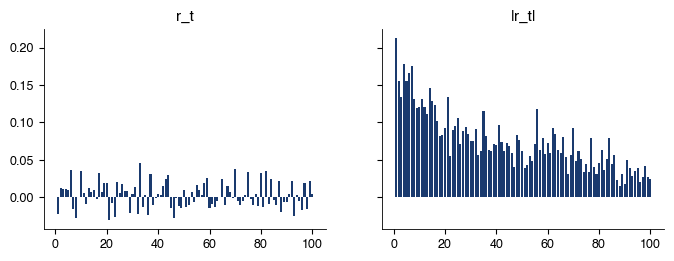

acf1 r = -0.022  acf1 |r| = 0.213
    lb_stat  lb_pvalue
10   20.178      0.028
    lb_stat  lb_pvalue
10  212.745        0.0
ARCH-LM(5) = 114.7


In [18]:
# Solution
r = rets['btc']
fig, ax = plt.subplots(1, 2, figsize=(8, 2.6), sharey=True)
for axi, s_, t in [(ax[0], r, 'r_t'), (ax[1], r.abs(), '|r_t|')]:
    axi.bar(range(1, 101), acf(s_, nlags=100, fft=True)[1:], color=MainBlue); axi.set_title(t)
plt.show()
print('acf1 r =', round(r.autocorr(1), 3), ' acf1 |r| =', round(r.abs().autocorr(1), 3))
print(acorr_ljungbox(r, lags=[10]).round(3)); print(acorr_ljungbox(r**2, lags=[10]).round(3))
print('ARCH-LM(5) =', round(het_arch(r - r.mean(), nlags=5)[0], 1))

### B4. Heteroskedasticity-robust Ljung–Box [Solved]

- S&P 500, BET-TR, EUR/RON, Bitcoin: classical $Q(10)$ and robust $\tilde Q(10) = \sum_k \hat\rho_k^2/\hat\tau_k$, $\hat\tau_k = \sum x_t^2x_{t-k}^2/(\sum x_t^2)^2$ (Lobato, Nankervis and Savin, 2001), and the Dalla–Giraitis–Phillips (2022) version that keeps the significant cross terms $E[x_t^2x_{t-j}x_{t-k}]$.
- Interpretation:
  - for which series does autocorrelation survive?
  - which assumptions (finite fourth moment, zero cross terms) does $\tilde Q$ need?

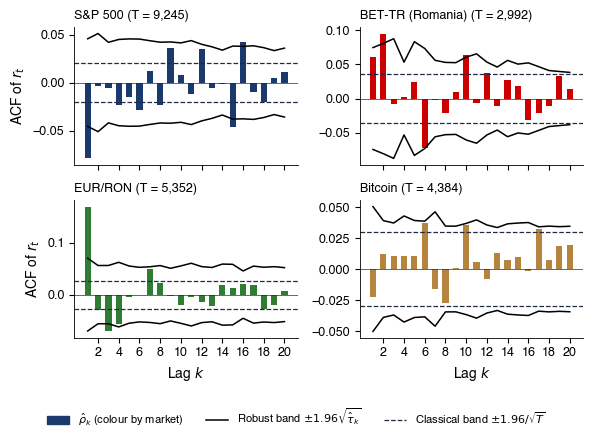

,T,Q10,Q10_p,Qt10,Qt10_p,sig_classic,sig_robust,robust_lags,rho1,Q_DGP,Q_DGP_p,n_cross_terms
asset,,,,,,,,,,,,
S&P 500,9245,91.553,0.000,18.976,0.041,8,3,"[1, 15, 16]",-0.079,18.976,0.041,0
BET-TR (Romania),2992,69.976,0.000,16.923,0.076,5,2,"[2, 10]",0.061,16.923,0.076,0
EUR/RON,5352,221.658,0.000,37.366,0.000,6,2,"[1, 3]",0.170,36.330,0.000,10
Bitcoin,4384,20.178,0.028,11.869,0.294,3,0,[],-0.022,11.869,0.294,0


In [19]:
# Solution
def dgp_q(r, m=10, lam=2.576):
    """Dalla, Giraitis & Phillips (2022): Q = t' R*^{-1} t, t_k = sum e_t e_{t-k} / sqrt(sum e_t^2 e_{t-k}^2);
    R* keeps only the significant cross terms (|tau_jk| > 2.576). R* = I gives the diagonal Q-tilde."""
    e = (r - r.mean()).values
    P = np.array([np.r_[np.zeros(k), e[k:] * e[:-k]] for k in range(1, m + 1)])
    d = np.sqrt((P ** 2).sum(1))
    t = P.sum(1) / d
    R = (P @ P.T) / np.outer(d, d)
    for j in range(m):
        for k in range(m):
            if j != k:
                pp = P[j] * P[k]
                if abs(pp.sum() / np.sqrt((pp ** 2).sum())) < lam:
                    R[j, k] = 0.0
    q = float(t @ np.linalg.solve(R, t))
    return q, float(stats.chi2.sf(q, m)), int((R != 0).sum() - m)


def robust_lb_table(assets=('sp500', 'bettr', 'eurron', 'btc'), m_q=10, m_band=20):
    rows = []
    for a in assets:
        x = (rets[a] - rets[a].mean()).values
        T, s2 = len(x), np.sum(x ** 2)
        ks = np.arange(1, m_band + 1)
        rho = np.array([np.sum(x[k:] * x[:-k]) / s2 for k in ks])
        tau = np.array([np.sum(x[k:] ** 2 * x[:-k] ** 2) / s2 ** 2 for k in ks])
        q = acorr_ljungbox(rets[a], lags=[m_q], return_df=True)
        qt = float(np.sum(rho[:m_q] ** 2 / tau[:m_q]))
        rows.append({'asset': LABELS[a], 'T': T, 'Q10': float(q['lb_stat'].iloc[0]), 'Q10_p': float(q['lb_pvalue'].iloc[0]),
                     'Qt10': qt, 'Qt10_p': float(stats.chi2.sf(qt, m_q)),
                     'sig_classic': int(np.sum(np.abs(rho) > 1.96 / np.sqrt(T))),
                     'sig_robust': int(np.sum(np.abs(rho) > 1.96 * np.sqrt(tau))),
                     'robust_lags': [int(k) for k in ks[np.abs(rho) > 1.96 * np.sqrt(tau)]], 'rho1': rho[0],
                     **dict(zip(['Q_DGP', 'Q_DGP_p', 'n_cross_terms'], dgp_q(rets[a], m_q)))})
    return pd.DataFrame(rows).set_index('asset')


def fig_robust_acf(assets=('sp500', 'bettr', 'eurron', 'btc'), m=20):
    """ACF of r_t (lags 1..m) with the classical i.i.d. band and the heteroskedasticity-robust band, 2 x 2 grid."""
    fig, axes = plt.subplots(2, 2, figsize=(6.0, 4.0), sharex=True)
    for ax, a in zip(axes.ravel(), assets):
        x = (rets[a] - rets[a].mean()).values
        T, s2 = len(x), np.sum(x ** 2)
        ks = np.arange(1, m + 1)
        rho = np.array([np.sum(x[k:] * x[:-k]) / s2 for k in ks])
        tau = np.array([np.sum(x[k:] ** 2 * x[:-k] ** 2) / s2 ** 2 for k in ks])
        ax.bar(ks, rho, color=COLORS[a], width=0.6, label='$\\hat\\rho_k$')
        ax.plot(ks, 1.96 * np.sqrt(tau), color='black', lw=1.1, label='Robust band $\\pm1.96\\sqrt{\\hat\\tau_k}$')
        ax.plot(ks, -1.96 * np.sqrt(tau), color='black', lw=1.1)
        ax.axhline(1.96 / np.sqrt(T), color=Navy, ls='--', lw=0.9, label='Classical band $\\pm1.96/\\sqrt{T}$')
        ax.axhline(-1.96 / np.sqrt(T), color=Navy, ls='--', lw=0.9)
        ax.axhline(0, color=Navy, lw=0.5)
        ax.set_xticks(ks[1::2])
        ax.set_title(f'{LABELS[a]} (T = {T:,})', fontsize=9, loc='left')
    for ax in axes[1]:
        ax.set_xlabel('Lag $k$')
    for ax in axes[:, 0]:
        ax.set_ylabel('ACF of $r_t$')
    h = [plt.Rectangle((0, 0), 1, 1, color=MainBlue), plt.Line2D([], [], color='black', lw=1.1),
         plt.Line2D([], [], color=Navy, ls='--', lw=0.9)]
    l = ['$\\hat\\rho_k$ (colour by market)', 'Robust band $\\pm1.96\\sqrt{\\hat\\tau_k}$', 'Classical band $\\pm1.96/\\sqrt{T}$']
    plt.tight_layout()
    fig.legend(h, l, loc='upper center', bbox_to_anchor=(0.5, 0.0), ncol=3, frameon=False)
    save_fig('ch1_sem_robust_acf')


fig_robust_acf()
robust_lb_table().round(3)

### B5. Aggregational Gaussianity (Bitcoin), with approximate standard errors [Proposed]

- Bitcoin: non-overlapping $h$-day log returns for $h = 1, 5, 20$; excess kurtosis and the reference value $\sqrt{24/N}$, the standard error under i.i.d. returns from the Normal distribution (not an uncertainty estimate for these heavy-tailed, dependent data).
- Interpretation:
  - why is $\sqrt{24/N}$ too optimistic here?
  - why do non-overlapping blocks remove the shared days but not the dependence of volatility?

In [ ]:
# Your code here


### B7. A kurtosis that does not converge [Proposed]

- S&P 500 excess kurtosis on expanding windows (first $n$ years, $n = 1..36$) against 5–95% bands of 500 simulated Student-t paths with $\nu = 3$ and $\nu = 6$.
- Interpretation:
  - why does the curve settle for $\nu = 6$ but not for $\nu = 3$?
  - what does 'excess kurtosis = 10.9' mean then?

In [ ]:
# Your code here


### B8. Which stylised facts does GARCH(1,1)-t reproduce? [Proposed]

- Fit a GARCH(1,1) with Student-t innovations to the S&P 500 (decimal returns converted to % in the code); simulate 200 paths and build 5–95% bands for excess kurtosis, ACF of $|r_t|$ at lags 1, 20, 100, 250, the Hill index and $L(1)$.
- Interpretation:
  - which facts are reproduced?
  - does the fitted model have a finite fourth moment?
  - which component would you change for each fact not reproduced?

In [ ]:
# Your code here


### B9. Leverage effect: Romania (BET-TR) vs crypto (Bitcoin) [Proposed]

- BET-TR and Bitcoin: leverage correlation $L(k) = \text{corr}(r_t, |r_{t+k}|)$, $k = -20, \dots, 20$, with each series' i.i.d. reference band $\pm 1.96/\sqrt{T}$.
- Interpretation:
  - why is the leverage effect weaker for Bitcoin?
  - is a correlation enough?

In [ ]:
# Your code here


### B10. The leverage effect as a regression (Newey–West errors, |r| controls) [Proposed]

- Regression $|r_{t+1}| = c + \beta^+ r_t^+ + \beta^- r_t^- + \sum_{j=1}^5\delta_j|r_{t-j}| + u_{t+1}$ for the S&P 500, BET-TR, Bitcoin and EUR/RON, with Newey–West SEs; Wald test of $H_0: \beta^+ + \beta^- = 0$ (symmetric response).
- Interpretation:
  - which sign do you expect for EUR/RON?
  - why control for $|r_{t-j}|$ but not $|r_t|$?

In [ ]:
# Your code here


### B11. EUR/RON across regimes [Proposed]

- EUR/RON (BNR) in July 2005–2011, 2012–2019, 2020–2026: $\hat\rho_1$ as the slope of $r_t$ on $r_{t-1}$ with its HAC (Newey–West) SE, volatility, excess kurtosis; the variance break by the cumulative sum of squares; Wald test of equal $\rho_1$.
- Interpretation:
  - why is the 2020–2026 SE so large?
  - why is the CUSUM break date descriptive rather than a test?

In [ ]:
# Your code here


### B12. Long memory or breaks? Local Whittle d for |r_t| [Proposed]

- Local Whittle $d$ of $|r_t|$ (S&P 500, BET-TR, Bitcoin) with $m = T^{0.65}$ and SE $1/(2\sqrt m)$; re-estimate on each side of the CUSUM-of-squares variance break and for $m = T^{0.5}, T^{0.8}$. The before/after $z$ is descriptive: the break date is estimated from the same data.
- Interpretation:
  - is $\hat d > 0$ robust to the break and to $m$?
  - long memory or regimes?

In [ ]:
# Your code here


### B13. BET-TR vs S&P 500 on the same period [Proposed]

- Align BET-TR and S&P 500 prices on common dates, then compute returns: CAGR, volatility, Sharpe, Sortino, MDD, Calmar.
- Interpretation: give three reasons why the comparison is only descriptive (dividends, currency, the RON risk-free rate).

In [ ]:
# Your code here


### B14. Is the Sharpe difference real? (Jobson–Korkie with the Memmel correction, block bootstrap) [Proposed]

- BET-TR vs S&P 500 on common days: Jobson–Korkie test with the Memmel correction on daily Sharpe ratios; 95% percentile interval from a circular block bootstrap (21-day blocks, 2,000 resamples); same-day, lag and lead correlations and the weekly correlation.
- Interpretation:
  - what do the test and the bootstrap assume (moments, dependence)?
  - why is the weekly correlation close to the sum of the three daily ones?
  - which correlation belongs in a portfolio?

In [ ]:
# Your code here


### B15. Range-based estimators on the S&P 500 (2008–2026) [Proposed]

- S&P 500 index 2008–2026: 21-day close-to-close, Parkinson, Garman–Klass, Rogers–Satchell and Yang–Zhang volatilities and their averages; compare with SPY (open, high, low multiplied by the ratio of the adjusted close to the close).
- Interpretation: why does Yang–Zhang stay below close-to-close on the index?

In [ ]:
# Your code here


## After the lecture — A5, B6, A6

- Seminar 1 takes place before Lecture 1: these tasks use tools introduced in the lecture (the Hill tail index and the variance of the autocorrelation); work on them after it, before the next seminar.

### A5. The Hill estimator, step by step (hypothetical sample) [Solved]

- The 11 largest absolute returns (%) 12.0, 9.5, 8.2, 7.4, 6.9, 6.1, 5.8, 5.5, 5.2, 5.0, 4.8: compute the Hill estimate for $k = 10$, its SE and 95% interval; repeat on BET-TR.
- Interpretation: can you decide whether the fourth moment exists?

In [30]:
# A5 The Hill estimator, step by step (hypothetical sample)
X = np.array([12.0, 9.5, 8.2, 7.4, 6.9, 6.1, 5.8, 5.5, 5.2, 5.0, 4.8])
k = 10
logs = np.log(X[:k] / X[k]); alpha = 1 / logs.mean(); se = alpha / np.sqrt(k)
print('logs =', logs.round(3), ' sum =', round(logs.sum(), 3))
print(f'alpha = {alpha:.2f}  SE = {se:.2f}  95% = [{alpha - 1.96 * se:.2f}, {alpha + 1.96 * se:.2f}]')
# the same on the 11 largest BET-TR days
x = np.sort(rets['bettr'].abs().values)[::-1][:11] * 100
print('BET-TR:', x.round(3), ' alpha_10 =', round(1 / np.mean(np.log(x[:10] / x[10])), 2))

logs = [0.916 0.683 0.536 0.433 0.363 0.24  0.189 0.136 0.08  0.041]  sum = 3.616
alpha = 2.77  SE = 0.87  95% = [1.05, 4.48]
BET-TR: [11.857 10.075  7.827  6.707  6.662  6.512  5.972  5.928  5.49   5.285
  5.202]  alpha_10 = 3.38


### B6. Hill on both tails, BET-TR and Bitcoin [Solved]

- BET-TR and Bitcoin: Hill plots of losses and gains, estimates at $k = 2\%$ of $n$ with 95% intervals $\hat\alpha(1 \pm 1.96/\sqrt{k})$ and a $z$-test of equal tails; these intervals and the test assume independent tail observations (i.i.d. benchmark).
- Interpretation:
  - with clustered extremes, is the true SE larger or smaller?
  - which of $\hat\alpha$ and the Student-t $\hat\nu$ describes the tail?

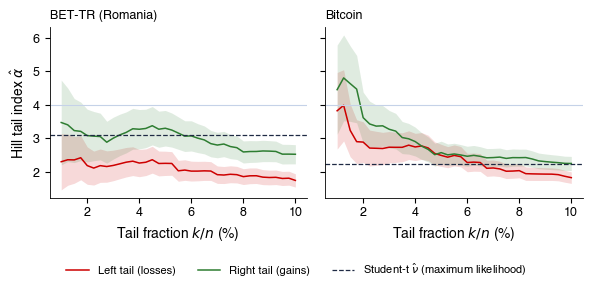

asset,BET-TR (Romania),Bitcoin
n,2992,4384
k,59,87
alpha_left,2.189264,2.890881
ci_left,"(1.6306288103270705, 2.7478988849206885)","(2.283408794914191, 3.498354084353436)"
alpha_right,3.084439,3.620397
ci_right,"(2.2973816746320073, 3.871495770206749)","(2.8596285657231864, 4.381166129741307)"
z_diff,-1.817879,-1.468704
p_diff,0.069083,0.141913
nu_mle,3.097034,2.229264


In [31]:
# Solution
def hill_tails(assets=('bettr', 'btc'), frac=0.02):
    rows = []
    for a in assets:
        r = rets[a]
        k = int(frac * len(r))
        aL, aR = hill_estimator(-r.values, k), hill_estimator(r.values, k)
        z = (r - r.mean()) / r.std()
        nu = stats.t.fit(z)[0]
        zdiff = (aL - aR) / np.sqrt(aL ** 2 / k + aR ** 2 / k)
        rows.append({'asset': LABELS[a], 'n': len(r), 'k': k, 'alpha_left': aL,
                     'ci_left': (aL * (1 - 1.96 / np.sqrt(k)), aL * (1 + 1.96 / np.sqrt(k))),
                     'alpha_right': aR,
                     'ci_right': (aR * (1 - 1.96 / np.sqrt(k)), aR * (1 + 1.96 / np.sqrt(k))),
                     'z_diff': zdiff, 'p_diff': 2 * stats.norm.sf(abs(zdiff)), 'nu_mle': nu})
    return pd.DataFrame(rows).set_index('asset')


def fig_hill_tails(assets=('bettr', 'btc')):
    fig, axes = plt.subplots(1, len(assets), figsize=(6.0, 2.6), sharey=True)
    for ax, a in zip(axes, assets):
        r = rets[a].values
        for side, x, c, lab in [('left', -r, IDAred, 'Left tail (losses)'), ('right', r, Forest, 'Right tail (gains)')]:
            ks = np.array([max(int(f * len(r)), 5) for f in HILL_FRACS_TAILS])
            al = np.array([hill_estimator(x, k) for k in ks])
            ax.plot(100 * HILL_FRACS_TAILS, al, color=c, lw=1.1, label=lab)
            ax.fill_between(100 * HILL_FRACS_TAILS, al * (1 - 1.96 / np.sqrt(ks)), al * (1 + 1.96 / np.sqrt(ks)),
                            color=c, alpha=0.15, lw=0)
        z = (rets[a] - rets[a].mean()) / rets[a].std()
        ax.axhline(stats.t.fit(z)[0], color=Navy, ls='--', lw=0.9, label='Student-t $\\hat\\nu$ (maximum likelihood)')
        ax.axhline(4, color=BandBlue, lw=0.8)
        ax.set_title(LABELS[a], fontsize=9, loc='left')
        ax.set_xlabel('Tail fraction $k/n$ (%)')
    axes[0].set_ylabel('Hill tail index $\\hat\\alpha$')
    h, l = axes[0].get_legend_handles_labels()
    fig.legend(h, l, loc='upper center', bbox_to_anchor=(0.5, 0.02), ncol=3, frameon=False)
    plt.tight_layout()
    save_fig('ch1_sem_hill_tails')


fig_hill_tails()
hill_tails().T

### A6. Why the autocorrelation band widens under clustering [Proposed]

- $x_t = \sigma_t\varepsilon_t$ (martingale difference): $T\,\text{Var}(\hat\rho_1) \to E[x_t^2x_{t-1}^2]/(E x_t^2)^2$. Compute it for the i.i.d. mixture of A4 and the Markov regimes of A9, and the i.i.d. and robust $t$-statistics of the S&P 500 lag-1 autocorrelation.
- Interpretation: does the band widen because of heavy tails or because of clustering?

In [ ]:
# Your code here


## Part C — open questions and AI critique

### C1. Critique of an AI answer [Proposed]

- Prompt sent to an AI assistant: "Are the daily log returns of BET-TR Normally distributed? Are they autocorrelated? Give Python code and a conclusion."
- The assistant's conclusion: "Excess kurtosis 14.8: heavy tails"; "JB p-value 0.000: the probability that BET-TR returns follow the Normal distribution is 0%"; "Ljung–Box $Q(10) = 713.5$, $p < 0.001$: returns are strongly autocorrelated, so BET-TR is predictable and not a random walk".
- (1) Find every substantive error in the code and in the three conclusions. (2) For each error, say how you would detect it: a test on simulated data, a number from the primer slides, a solved exercise or the library documentation. (3) Write corrected, runnable code and report the excess kurtosis, JB with its p-value, $Q(10)$ on $r_t$ and on $r_t^2$, and the robust $\tilde Q(10)$ of B4. (4) State the assumptions behind the robust p-value. (5) Write the corrected conclusion in three sentences.
- Report: the corrected code, a table AI value / correct value, and an ACF chart of $r_t$ and $r_t^2$; log what you find in `AI_ERRORS.md`.

In [ ]:
# The assistant's code, unchanged (it runs without an error message)
bet = pd.DataFrame({'close': closes['bettr']})
from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox
r = np.log(bet["close"]).diff().dropna()     # daily log returns
k = stats.kurtosis(r)                         # sample kurtosis
print("excess kurtosis:", k - 3)              # the Normal has kurtosis 3
jb, p = stats.jarque_bera(r)
lb = acorr_ljungbox(r**2, lags=[10])          # Ljung-Box, 10 lags
print('JB p-value:', p)
lb

In [ ]:
# Your code here


### C2. Did BET-TR autocorrelation fall after the 2020 FTSE reclassification? [Proposed]

- Rolling one-year lag-1 autocorrelation of BET-TR with robust bands; before/after comparison (21 September 2020) with HAC standard errors and an interaction regression; relation to the traded value of 11 BVB blue chips.
- Interpretation:
  - did autocorrelation fall?
  - is liquidity the explanation?
  - which alternatives (index composition, new listings) remain?

In [ ]:
# Your code here


### C3. Is the VIX mostly path-dependent? [Proposed]

- A replication project (Guyon and Lekeufack, 2023; the case study of Lecture 1): can past S&P 500 returns alone explain the VIX?
- Data: daily closes of the S&P 500, the VIX and the 9-day VIX; simple returns; volatility indices divided by 100. Model (eq. 3.7 in the paper): $\sigma_t = \beta_0 + \beta_1 R_{1,t} + \beta_2\Sigma_t$ with time-shifted power-law kernels on the last 1,000 days.
- (1) With the kernels of Table 3 of the paper, estimate $\beta_0, \beta_1, \beta_2$ by OLS on 2000–2018. (2) Estimate all seven parameters by nonlinear least squares on 1 Jan 2000 – 31 Dec 2018. (3) Report $R^2$ and RMSE on training and on 1 Jan 2019 – 15 May 2022, for the full model and for $\beta_1 = 0$ and $\beta_2 = 0$; repeat the full model for the 9-day VIX (training from 2011). (4) Keep the parameters fixed and evaluate 16 May 2022 – 18 Sep 2026.
- Interpretation: the model explains the same-day VIX, it is not a next-day forecast; which variable explains more, $R_{1,t}$ or $\Sigma_t$?

In [ ]:
# C3: your analysis here